<a href="https://colab.research.google.com/github/moawinds/BengKod_Alwi/blob/main/UAS_BENGKOD_ALWI_DS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UJIAN AKHIR SEMESTER**
# **BENGKEL KODING DATA SCIENCE**

**EDA**
*Unit Kompetensi: Mengolah data dan memvalidasi data.
Tugas:*

1. Menampilkan 5 Baris Pertama, Informasi Dataset, dan Statistik Deskriptif

> Langkah awal ini bertujuan untuk memahami struktur data, tipe data setiap kolom, serta melihat gambaran umum distribusi angka pada dataset.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# 1. Menampilkan 5 baris pertama
print("--- 5 Baris Pertama ---")
print(df.head())

# 2. Informasi Dataset
print("\n--- Informasi Dataset ---")
print(df.info())

# 3. Statistik Deskriptif
print("\n--- Statistik Deskriptif ---")
print(df.describe())

--- 5 Baris Pertama ---
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

2. Persentase Nilai Kosong (Missing Value) dan Visualisasi

> Kita akan menghitung seberapa banyak data yang hilang di setiap kolom agar bisa menentukan strategi pembersihan data nantinya.



/tmp/ipykernel_11313/1131519291.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentage.values, y=missing_percentage.index, palette='viridis')


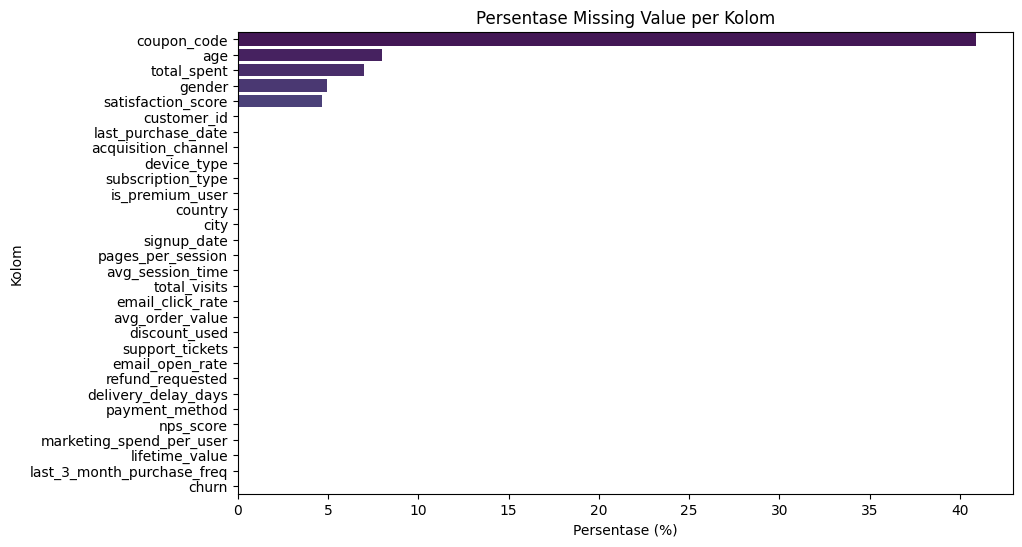

In [2]:
# Menghitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

# Visualisasi dengan Diagram Batang
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percentage.values, y=missing_percentage.index, palette='viridis')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('Persentase (%)')
plt.ylabel('Kolom')
plt.show()

3. Distribusi Variabel Target (Churn)

> Langkah ini krusial untuk melihat apakah data kita "seimbang" atau tidak. Jika jumlah pelanggan yang churn (berhenti) jauh lebih sedikit dibanding yang bertahan, kita harus berhati-hati dalam pembuatan model prediksi nanti.



/tmp/ipykernel_11313/1925194346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2')


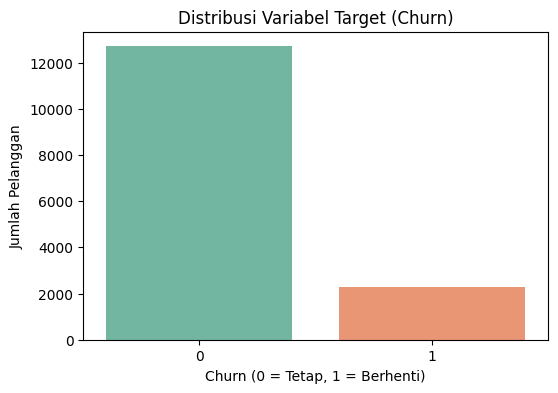

Persentase Churn:
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


In [3]:
# Visualisasi distribusi Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn (0 = Tetap, 1 = Berhenti)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Menampilkan persentase pastinya
churn_rate = df['churn'].value_counts(normalize=True) * 100
print(f"Persentase Churn:\n{churn_rate}")

4. Heatmap Korelasi Fitur Numerik

> Kita akan melihat hubungan antar variabel numerik (seperti total_visits, avg_order_value, marketing_spend, dll) terhadap churn. Korelasi yang mendekati 1 atau -1 menunjukkan hubungan yang kuat.



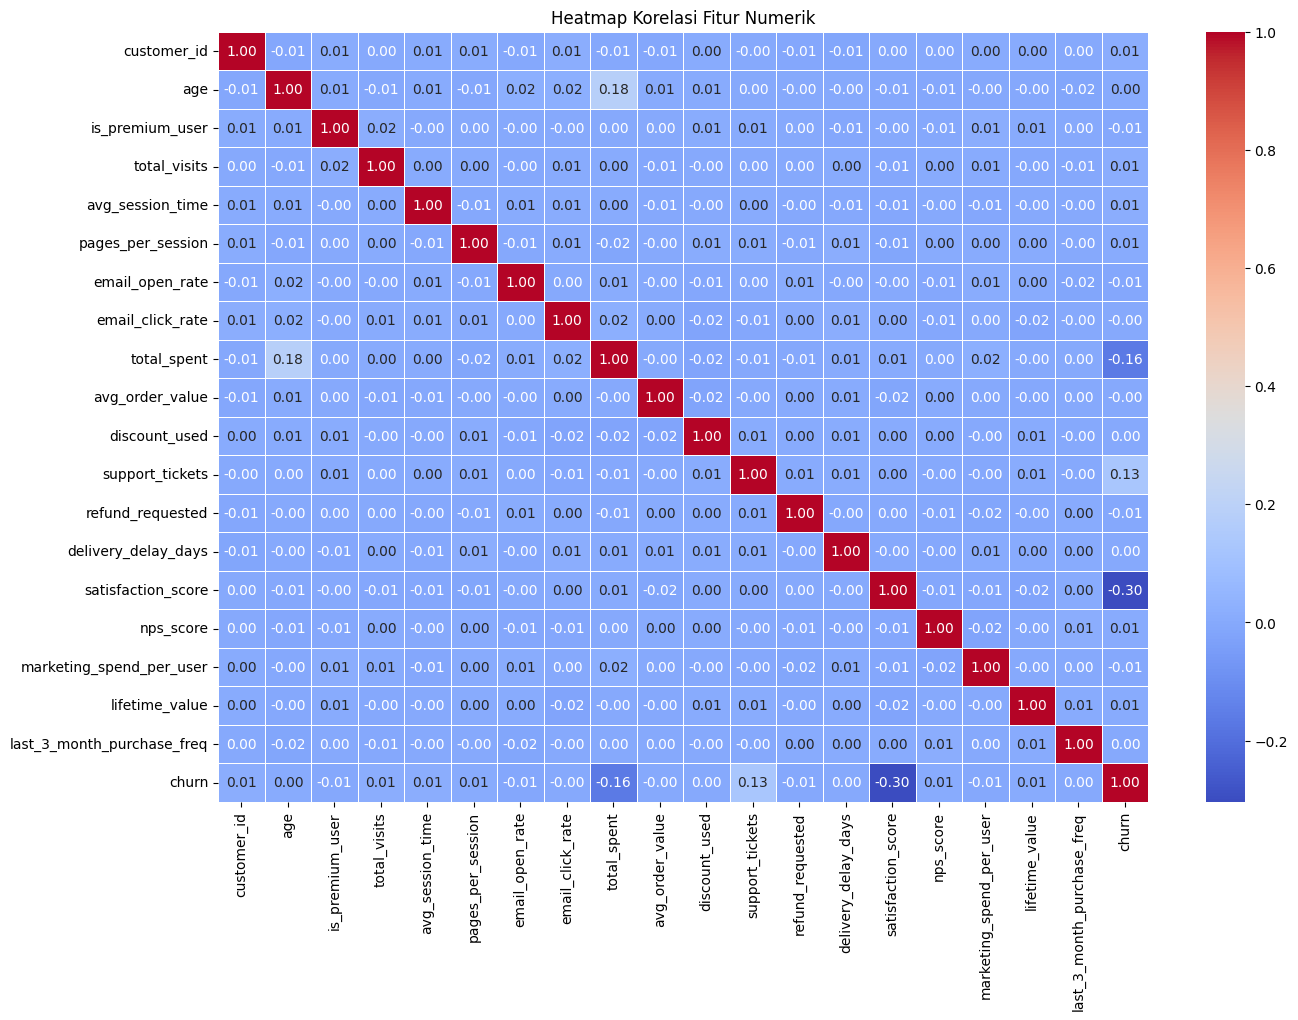

In [4]:
# Filter kolom numerik saja
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Menghitung korelasi
plt.figure(figsize=(15, 10))
correlation_matrix = numeric_df.corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()